In [37]:
import pandas as pd
from sklearn import datasets
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [5]:
iris=datasets.load_iris()

In [7]:
X=iris.data
y=iris.target

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [17]:
y_pred=model.predict(X_test)

In [21]:
accuracy=accuracy_score(y_test,y_pred)
print(f"model dogruluk oranı:{accuracy}")

model dogruluk oranı:1.0


In [23]:
model2=SVC(kernel='poly')
model2.fit(X_train,y_train)


SVC(kernel='poly')

In [25]:
y_pred2=model2.predict(X_test)

In [27]:
accuracy2=accuracy_score(y_test,y_pred2)

print(f"accuracy score:{accuracy2}")

accuracy score:1.0


In [35]:
def plot_confusion_matrix(cm,classes,normalize=False,title='Confusion Matrix',cmap=plt.cm.Blues):


    if normalize:
        cm=cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
        print("Normalized confusion matrix")

    else:
        print('Confusion matrix,without normalization')

    print(cm)


    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)


    fmt='.2f' if normalize else 'd'
    thresh=cm.max() / 2.
    for i,j  in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted Label')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix,without normalization
[[11  0]
 [ 0  0]]


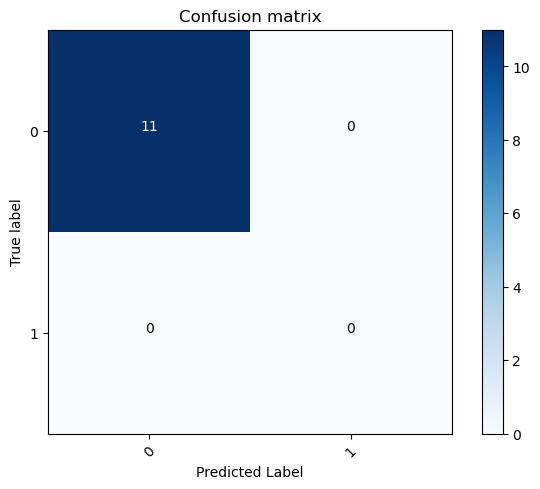

In [49]:
cnf_matrix=confusion_matrix(y_test,y_pred,labels=[2,4])
np.set_printoptions(precision=2)

print(classification_report(y_test,y_pred))

plt.figure()
plot_confusion_matrix(cnf_matrix,classes=['0','1'],normalize=False,title='Confusion matrix')